In [1]:
#get all the tables:
from db_setup import conn, currencyexchange, customer, date, product, sales, store
#instead of saving csv files in sql and then importing one by one
import pandas as pd
import numpy as np

customer_summary=pd.read_parquet(r"C:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\saved_files\customer_summary.parquet")
order_enriched=pd.read_parquet(r"C:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\saved_files\order_enriched.parquet")


c:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\db_setup.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  currencyexchange = pd.read_sql("SELECT * FROM currencyexchange", conn)
c:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\db_setup.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customer = pd.read_sql("SELECT * FROM customer", conn)
c:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\db_setup.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  date = pd.read_sql("SELECT * FR

1- Monthly trend (orders, rev and profit)

In [2]:
order_enriched["month"]=order_enriched["orderdate"].dt.to_period("M").dt.to_timestamp()

monthly_stats=(
    order_enriched
    .groupby("month")
    .agg(
        orders=("orderkey","nunique"),
        revenue=("order_revenue", "sum"),
        profit=("order_profit","sum")
    )
    .reset_index()
)

monthly_stats

,month,orders,revenue,profit
0,2015-01-01,200,4.923331e+05,2.802615e+05
1,2015-02-01,292,7.548905e+05,4.302068e+05
2,2015-03-01,139,3.804176e+05,2.194614e+05
3,2015-04-01,78,1.664742e+05,9.323730e+04
4,2015-05-01,236,6.155291e+05,3.417246e+05
...,...,...,...,...
107,2023-12-01,1500,2.729676e+06,1.523357e+06
108,2024-01-01,1353,2.605671e+06,1.455577e+06
109,2024-02-01,1749,3.311112e+06,1.855571e+06
110,2024-03-01,884,1.639757e+06,9.166870e+05


line chart:

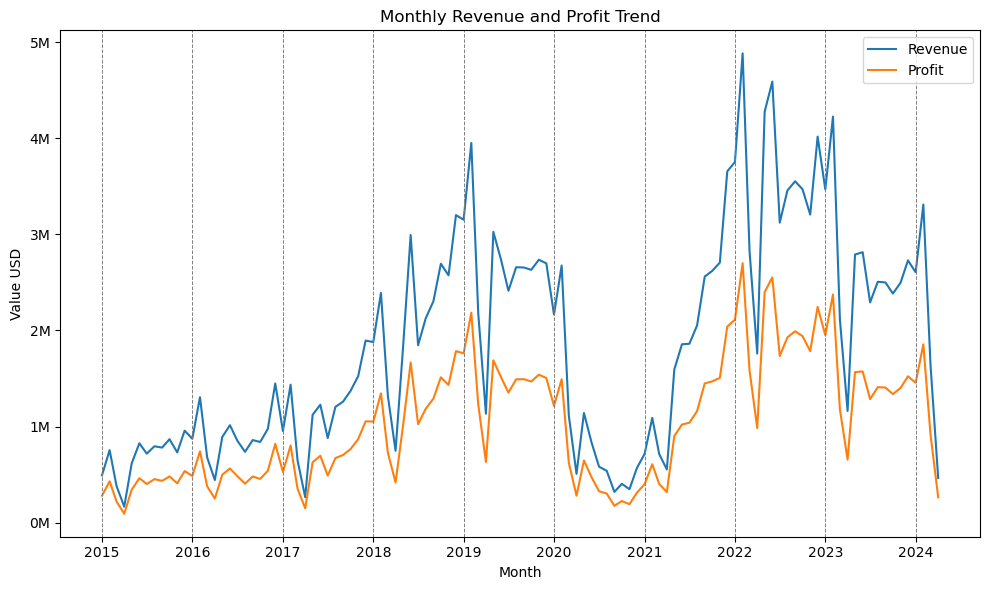

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,6))

plt.plot(monthly_stats["month"], monthly_stats["revenue"], label="Revenue")
plt.plot(monthly_stats["month"], monthly_stats["profit"], label="Profit")

#vertical lines on each year
years = monthly_stats["month"].dt.year.unique()

for y in years:
    plt.axvline(pd.Timestamp(f"{y}-01-01"), color="gray", linestyle="--", linewidth=0.7)


plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos: f'{y/1000000:.0f}M'))

plt.xlabel("Month")
plt.ylabel("Value USD")
plt.title("Monthly Revenue and Profit Trend")

plt.legend()
plt.tight_layout()


2- Seasonality

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


order_enriched2=order_enriched.copy()




monthly = (
    order_enriched2
    .assign(
        year=order_enriched2["orderdate"].dt.year,
        month=order_enriched2["orderdate"].dt.month,
        year_month=order_enriched2["orderdate"].dt.to_period("M")
    ) 
    .groupby("year_month")
    .agg(
        orders=("orderkey","nunique"),
        revenue=("order_revenue","sum"),
        profit=("order_profit","sum")
    )
    .reset_index()
)

monthly["month"] = monthly["year_month"].dt.month
monthly["year"]  = monthly["year_month"].dt.year

seasonality = (
    monthly
    .groupby("month")
    .agg(
        avg_orders=("orders","mean"),
        avg_revenue=("revenue","mean"),
        avg_profit=("profit","mean"),
        years_covered=("year","nunique")
    )
    .reset_index()
)

seasonality


,month,avg_orders,avg_revenue,avg_profit,years_covered
0,1,804.400000,2.006024e+06,1.124161e+06,10
1,2,1051.000000,2.602647e+06,1.453796e+06,10
2,3,561.000000,1.360899e+06,7.611556e+05,10
3,4,289.400000,7.206856e+05,4.047067e+05,10
4,5,753.000000,1.919429e+06,1.075491e+06,9
5,6,785.444444,2.099152e+06,1.169267e+06,9
6,7,670.555556,1.619029e+06,9.045115e+05,9
7,8,720.000000,1.786603e+06,1.001196e+06,9
8,9,764.111111,1.866206e+06,1.047551e+06,9
9,10,787.222222,1.920343e+06,1.073166e+06,9


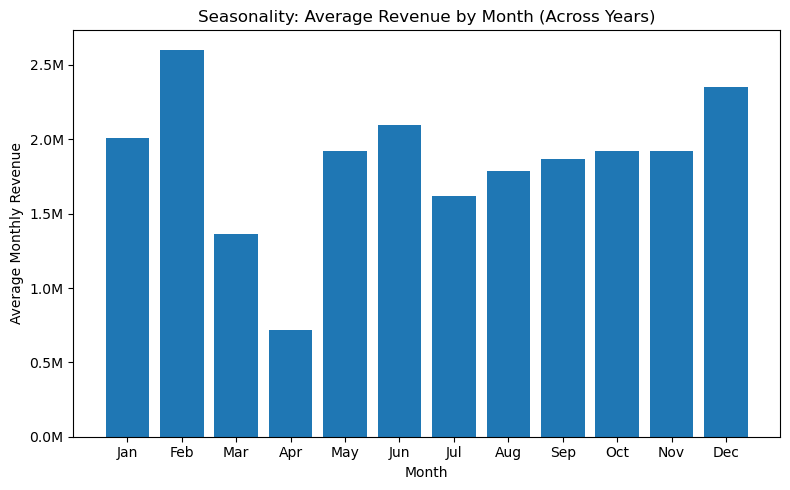

In [ ]:
#import calendar #chatgpt# - neede if i used the calendar.month_name option

plt.figure(figsize=(8,5))

plt.bar(seasonality["month"], seasonality["avg_revenue"])

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos: f'{y/1000000:.1f}M'))

plt.xlabel("Month")
plt.ylabel("Average Monthly Revenue")
plt.title("Seasonality: Average Revenue by Month (Across Years)")


month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
plt.xticks(range(1, 13), month_names)


plt.tight_layout()



3 - Orders by day of the week:

In [27]:
dow = (
    order_enriched
    .assign(dow=order_enriched["orderdate"].dt.dayofweek)
    .groupby("dow")
    .agg(orders=("orderkey","nunique"))
    .reset_index()
)

dow

,dow,orders
0,0,8791
1,1,11215
2,2,14762
3,3,15958
4,4,11190
5,5,19523
6,6,1691


Graph:

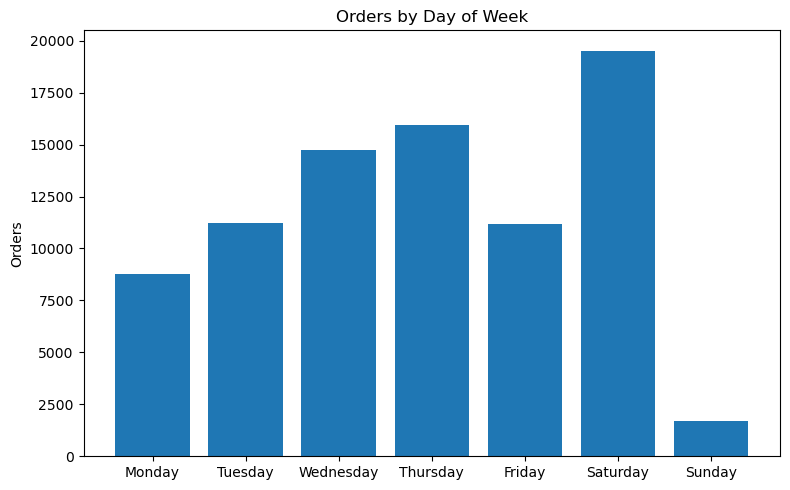

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(dow["dow"], dow["orders"])

days_label=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

plt.xticks(dow["dow"],days_label)

plt.xlabel("") 
plt.ylabel("Orders")
plt.title("Orders by Day of Week")

plt.tight_layout()
